    batch_size=64
    decision_threshold=0.7,
    positive_weight=0.7,
    epochs=50,
    learning_rate=3e-4,
    dropout_rate=0.3,

    monitor_start_sec=3.0,
    monitor_end_sec=8.0,

In [ ]:
import os
import sys
import sqlite3
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import gc
from pathlib import Path
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

In [ ]:
# 1. 환경 설정 및 드라이브 마운트
IN_COLAB = 'COLAB_RELEASE_TAG' in os.environ
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
MANUAL_PROJECT_ROOT = ''
PROJECT_ROOT_CANDIDATES = [
    '/content/drive/MyDrive/Graduate-Project/Falling-Detection-Development',
    '/content/drive/MyDrive/졸업 과제/Falling-Detection-Development',
    '/content/Falling-Detection-Development',
    str(Path.cwd()),
]

candidate_paths = [MANUAL_PROJECT_ROOT] + PROJECT_ROOT_CANDIDATES if MANUAL_PROJECT_ROOT else PROJECT_ROOT_CANDIDATES
PROJECT_ROOT = None
for candidate in candidate_paths:
    path = Path(candidate)
    if (path / 'scripts').exists() and (path / 'dataset').exists():
        PROJECT_ROOT = path.resolve()
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError('프로젝트 루트를 찾지 못했습니다. train_gru_v26.py 파일 위치를 확인하세요.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_ROOT = PROJECT_ROOT / 'dataset'
ARTIFACT_ROOT = PROJECT_ROOT / 'artifacts' / 'gru_v26_2_notebook'

print('PROJECT_ROOT =', PROJECT_ROOT)
print('DATA_ROOT =', DATA_ROOT)
print('ARTIFACT_ROOT =', ARTIFACT_ROOT)

PROJECT_ROOT = /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development
DATA_ROOT = /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset
ARTIFACT_ROOT = /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/artifacts/gru_v26_2_notebook


In [ ]:
# 2. train_gru_v26.py 및 기존 유틸리티 임포트
from scripts.train_gru_v26 import (
    GruV26TrainConfig,
    refine_labels
)
from scripts.train_tcn_v2 import (
    load_source_frame, log, set_seed, normalize_splits,
    make_tf_dataset, compile_model, build_split_metrics,
    save_run_metadata, save_visualization_artifacts, export_tflite_artifacts,
    train_model
)
from scripts.train_gru_v2 import build_gru_v2_model
from scripts.train_tcn_v25 import (
    build_monitoring_segments, build_sliding_window_dataset,
    describe_window_split, split_segments
)

In [ ]:
def build_gru_v2_model(config, input_shape):
    inputs = tf.keras.Input(shape=input_shape, name="pose_sequence")
    x = inputs

    for layer_idx, hidden_size in enumerate(config.hidden_sizes, start=1):
        return_sequences = layer_idx < len(config.hidden_sizes)
        x = tf.keras.layers.GRU(
            hidden_size,
            return_sequences=return_sequences,
            dropout=config.dropout_rate,
            recurrent_dropout=0.0,
            reset_after=True,
            unroll=True,
            activation='tanh',
            recurrent_activation='sigmoid',
            name=f"gru_{layer_idx}",
        )(x)

    x = tf.keras.layers.Dense(config.hidden_sizes[-1], activation="relu", name="head_dense")(x)
    x = tf.keras.layers.Dropout(config.dropout_rate, name="head_drop")(x)
    outputs = tf.keras.layers.Dense(2, activation="softmax", name="classifier")(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name="stm32_gru_v2_classifier")

In [ ]:
# 3. 설정 및 데이터 준비
config = GruV26TrainConfig(
    input_format='csv',
    csv_path=str(DATA_ROOT / 'final_dataset.csv'),
    sqlite_path=str(DATA_ROOT / 'final_dataset.sqlite'),
    sqlite_table='fall_frames',
    output_dir=str(ARTIFACT_ROOT),
    monitor_start_sec=0.0,
    monitor_end_sec=10.0,
    target_steps=60,
    label_mode='segment_max',
    batch_size=64,
    epochs=50,
    learning_rate=3e-4,
    random_state=42,
    dropout_rate=0.3,
    hidden_sizes=[64, 32],
    export_tflite=True,
    train_positive_stride=3,
    train_negative_stride=10,
    eval_stride=1,
    decision_threshold=0.7,
    min_val_recall=0.85,
    positive_weight=0.7,
    soft_label_value=0.9
)

set_seed(config.random_state)
df, feature_cols = load_source_frame(config)
segments = build_monitoring_segments(df, feature_cols, config.monitor_start_sec, config.monitor_end_sec)

del df
gc.collect()

[2026-04-21 00:45:50] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-21 00:47:07] csv rows loaded=4093620 feature_count=55


0

In [ ]:
split_maps = split_segments(segments, config.random_state)


x_train, y_train, group_train = build_sliding_window_dataset(
    split_maps["train"],
    config.target_steps,
    config.label_mode,
    training=True,
    positive_stride=config.train_positive_stride,
    negative_stride=config.train_negative_stride,
    eval_stride=config.eval_stride
)

In [ ]:
x_val, y_val, group_val = build_sliding_window_dataset(
    split_maps["val"],
    config.target_steps,
    config.label_mode,
    training=False,
    positive_stride=config.train_positive_stride,
    negative_stride=config.train_negative_stride,
    eval_stride=config.eval_stride
)

x_test, y_test, group_test = build_sliding_window_dataset(
    split_maps["test"],
    config.target_steps,
    config.label_mode,
    training=False,
    positive_stride=config.train_positive_stride,
    negative_stride=config.train_negative_stride,
    eval_stride=config.eval_stride
)

del segments, split_maps
gc.collect()

0

In [ ]:
# 데이터 정규화
mean = np.mean(x_train, axis=(0, 1))
std = np.std(x_train, axis=(0, 1)) + 1e-7

x_train -= mean
x_train /= std

x_val -= mean
x_val /= std

x_test -= mean
x_test /= std

gc.collect()

0

In [ ]:
# 데이터 정규화 (cpu 부족)
#x_train, x_val, x_test, mean, std = normalize_splits(x_train, x_val, x_test)

#gc.collect()

In [ ]:
print(f"최종 학습 데이터 크기: {x_train.nbytes / 1e9:.2f} GB")

최종 학습 데이터 크기: 5.38 GB


In [ ]:
# 4. 시각화 및 평가 함수
def plot_history(history):
    history_df = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    history_df[['loss', 'val_loss']].plot(ax=axes[0], marker='o')
    axes[0].set_title('Training & Validation Loss')
    axes[1].set_title('Metric Curves')
    history_df[[col for col in ['accuracy', 'val_accuracy', 'recall', 'val_recall'] if col in history_df.columns]].plot(ax=axes[1], marker='o')
    plt.show()

def plot_confusion(cm, split_name):
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{split_name} Confusion Matrix')
    plt.show()

In [ ]:
# 대체용 dataset 생성 코드

def make_tf_dataset(x, y, batch_size, training=True):
    with tf.device('/cpu:0'):
        dataset = tf.data.Dataset.from_tensor_slices((x, y))

        if training:
            dataset = dataset.shuffle(buffer_size=min(len(x), 50000))

        dataset = dataset.batch(batch_size)
        dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [ ]:
# 5. v26 2단계 학습 파이프라인 실행
model = build_gru_v2_model(config, input_shape=(config.target_steps, len(feature_cols)))
model = compile_model(model, config.learning_rate)
class_weight = {0: 1.0, 1: config.positive_weight}

print("\n[STEP 1] Initial Training...")
train_model(model, make_tf_dataset(x_train, y_train, 64, True),
                  make_tf_dataset(x_val, y_val, 64, False), 15, class_weight)

gc.collect()


[STEP 1] Initial Training...
Epoch 1/15
6366/6366 ━━━━━━━━━━━━━━━━━━━━ 228s 23ms/step - accuracy: 0.8086 - loss: 0.3442 - pr_auc: 0.9334 - precision: 0.8501 - recall: 0.8733 - val_accuracy: 0.8253 - val_loss: 0.3997 - val_pr_auc: 0.9094 - val_precision: 0.7475 - val_recall: 0.8759 - learning_rate: 3.0000e-04
Epoch 2/15
6366/6366 ━━━━━━━━━━━━━━━━━━━━ 80s 13ms/step - accuracy: 0.8457 - loss: 0.2736 - pr_auc: 0.9627 - precision: 0.9043 - recall: 0.8653 - val_accuracy: 0.8403 - val_loss: 0.3711 - val_pr_auc: 0.9219 - val_precision: 0.7670 - val_recall: 0.8850 - learning_rate: 3.0000e-04
Epoch 3/15
6366/6366 ━━━━━━━━━━━━━━━━━━━━ 78s 12ms/step - accuracy: 0.8545 - loss: 0.2584 - pr_auc: 0.9670 - precision: 0.9129 - recall: 0.8696 - val_accuracy: 0.8515 - val_loss: 0.3529 - val_pr_auc: 0.9260 - val_precision: 0.7906 - val_recall: 0.8747 - learning_rate: 3.0000e-04
Epoch 4/15
6366/6366 ━━━━━━━━━━━━━━━━━━━━ 82s 13ms/step - accuracy: 0.8593 - loss: 0.2505 - pr_auc: 0.9692 - precision: 0.9186 - 

120

In [ ]:
print("\n[STEP 2] Self-Labeling Process...")
y_train_refined = refine_labels(model, x_train, y_train, soft_value=config.soft_label_value)

gc.collect()


[STEP 2] Self-Labeling Process...
[2026-04-21 01:10:37] >>> STAGE 2: Refining labels based on Stage 1 predictions
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 34s 13ms/step
[2026-04-21 01:11:21] Self-labeling: Refined 28479 normal samples to 0.9


331

In [ ]:
# epoch 조절
# config.epochs=1

print("\n[STEP 3] Final Fine-tuning...")
history = train_model(
    model,
    make_tf_dataset(x_train, y_train_refined, config.batch_size, True),
    make_tf_dataset(x_val, y_val, config.batch_size, False),
    config.epochs,
    class_weight
)

gc.collect()


[STEP 3] Final Fine-tuning...
Epoch 1/50
6366/6366 ━━━━━━━━━━━━━━━━━━━━ 183s 19ms/step - accuracy: 0.8536 - loss: 0.1991 - pr_auc: 0.9921 - precision: 0.9174 - recall: 0.9026 - val_accuracy: 0.8619 - val_loss: 0.3224 - val_pr_auc: 0.9411 - val_precision: 0.7931 - val_recall: 0.9039 - learning_rate: 3.0000e-04
Epoch 2/50
6366/6366 ━━━━━━━━━━━━━━━━━━━━ 78s 12ms/step - accuracy: 0.8548 - loss: 0.1978 - pr_auc: 0.9922 - precision: 0.9173 - recall: 0.9044 - val_accuracy: 0.8556 - val_loss: 0.3386 - val_pr_auc: 0.9400 - val_precision: 0.7817 - val_recall: 0.9060 - learning_rate: 3.0000e-04
Epoch 3/50
6366/6366 ━━━━━━━━━━━━━━━━━━━━ 78s 12ms/step - accuracy: 0.8559 - loss: 0.1973 - pr_auc: 0.9923 - precision: 0.9162 - recall: 0.9060 - val_accuracy: 0.8573 - val_loss: 0.3210 - val_pr_auc: 0.9414 - val_precision: 0.7826 - val_recall: 0.9096 - learning_rate: 3.0000e-04
Epoch 4/50
6366/6366 ━━━━━━━━━━━━━━━━━━━━ 78s 12ms/step - accuracy: 0.8566 - loss: 0.1969 - pr_auc: 0.9923 - precision: 0.9168 -

130

[2026-04-21 02:07:04] using fixed decision threshold threshold=0.5000


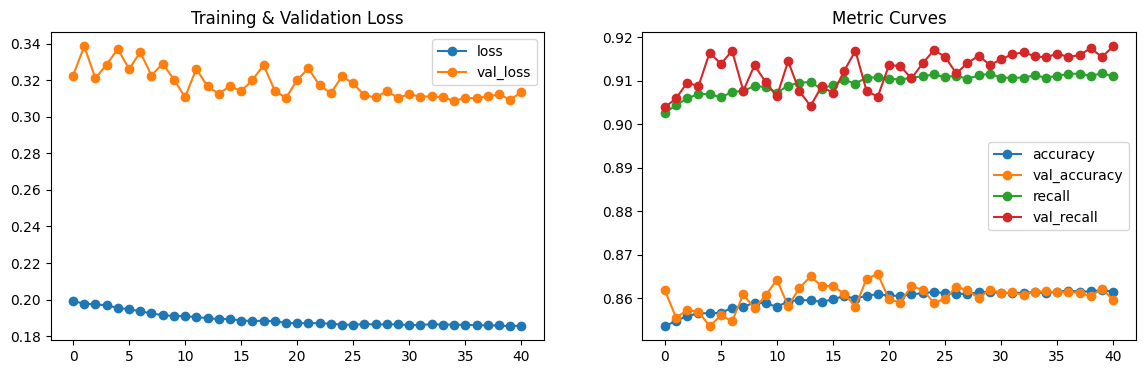

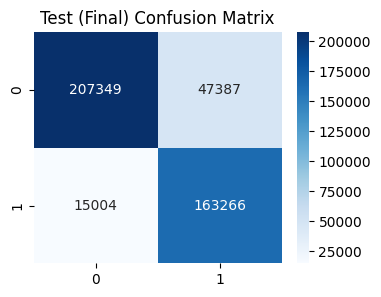

In [ ]:
# 6. 결과 저장 및 최종 시각화
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
metrics = build_split_metrics(model, x_train, y_train > 0.5, x_val, y_val > 0.5, x_test, y_test > 0.5, decision_threshold=0.5, min_val_recall=config.min_val_recall)

plot_history(history)
plot_confusion(np.array(metrics['test']['confusion_matrix']), 'Test (Final)')

In [ ]:
# 1. TFLite 및 메타데이터 저장 경로 설정
export_paths = {"keras": str(ARTIFACT_ROOT / "gru_v26.keras")}

try:
    # 2. 모델 및 TFLite 변환 실행
    model.save(export_paths["keras"])
    if config.export_tflite:
        print(" TFLite 변환을 시작...")
        export_paths.update(export_tflite_artifacts(model, x_train, ARTIFACT_ROOT, "gru_v26"))

    # 3. 메타데이터 저장
    save_run_metadata(config, feature_cols, mean, std, {}, metrics, history, export_paths)
    print(f"\n 학습 완료! 결과 저장 위치: {ARTIFACT_ROOT}")

except Exception as e:
    print(f"\n 중간에 에러가 발생했지만 파일 확인을 시도합니다: {e}")

print("\n--- 학습 결과 리포트 ---")
if 'best_threshold' in metrics:
    print(f"최종 Best Threshold: {metrics['best_threshold']:.4f}")
elif 'threshold_selection' in metrics:
    ts = metrics['threshold_selection']
    if isinstance(ts, dict) and 'threshold' in ts:
        print(f"선택된 Threshold (from selection): {ts['threshold']:.4f}")
    else:
        print(f"Threshold 정보 (threshold_selection): {ts}")
else:
    print("최종 Threshold: (기록된 값이 없음)")

 TFLite 변환을 시작...
Saved artifact at '/tmp/tmpyc8n1hyw'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 60, 55), dtype=tf.float32, name='pose_sequence')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  138205315283280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138203730096976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138203730094480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138203730097168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138203730093136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138203730098128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138203730094864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138203730095440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138203730095632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138203730097552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(



 학습 완료! 결과 저장 위치: /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/artifacts/gru_v26_2_notebook

--- 학습 결과 리포트 ---
Threshold 정보 (threshold_selection): {'source': 'cli', 'selected_threshold': 0.5, 'min_val_recall': 0.85}


------------------------------------------------

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path
import gc

In [ ]:
model_path = str(ARTIFACT_ROOT / "gru_v26.keras")
model = tf.keras.models.load_model(model_path, compile=False)

In [ ]:
# 3. 설정 및 데이터 준비
config = GruV26TrainConfig(
    input_format='csv',
    csv_path=str(DATA_ROOT / 'final_dataset.csv'),
    sqlite_path=str(DATA_ROOT / 'final_dataset.sqlite'),
    sqlite_table='fall_frames',
    output_dir=str(ARTIFACT_ROOT),
    monitor_start_sec=0.0,
    monitor_end_sec=10.0,
    target_steps=60,
    label_mode='segment_max',
    batch_size=64,
    epochs=50,
    learning_rate=3e-4,
    random_state=42,
    dropout_rate=0.3,
    hidden_sizes=[64, 32],
    export_tflite=True,
    train_positive_stride=3,
    train_negative_stride=10,
    eval_stride=1,
    decision_threshold=0.7,
    min_val_recall=0.85,
    positive_weight=0.7,
    soft_label_value=0.9
)

set_seed(config.random_state)
df, feature_cols = load_source_frame(config)

[2026-04-21 02:11:48] loading csv source from /content/drive/.shortcut-targets-by-id/1sPM3m7rEt6UUnWt9ulH3rzFYhguMJMUY/졸업 과제/Falling-Detection-Development/dataset/final_dataset.csv
[2026-04-21 02:12:48] csv rows loaded=4093620 feature_count=55


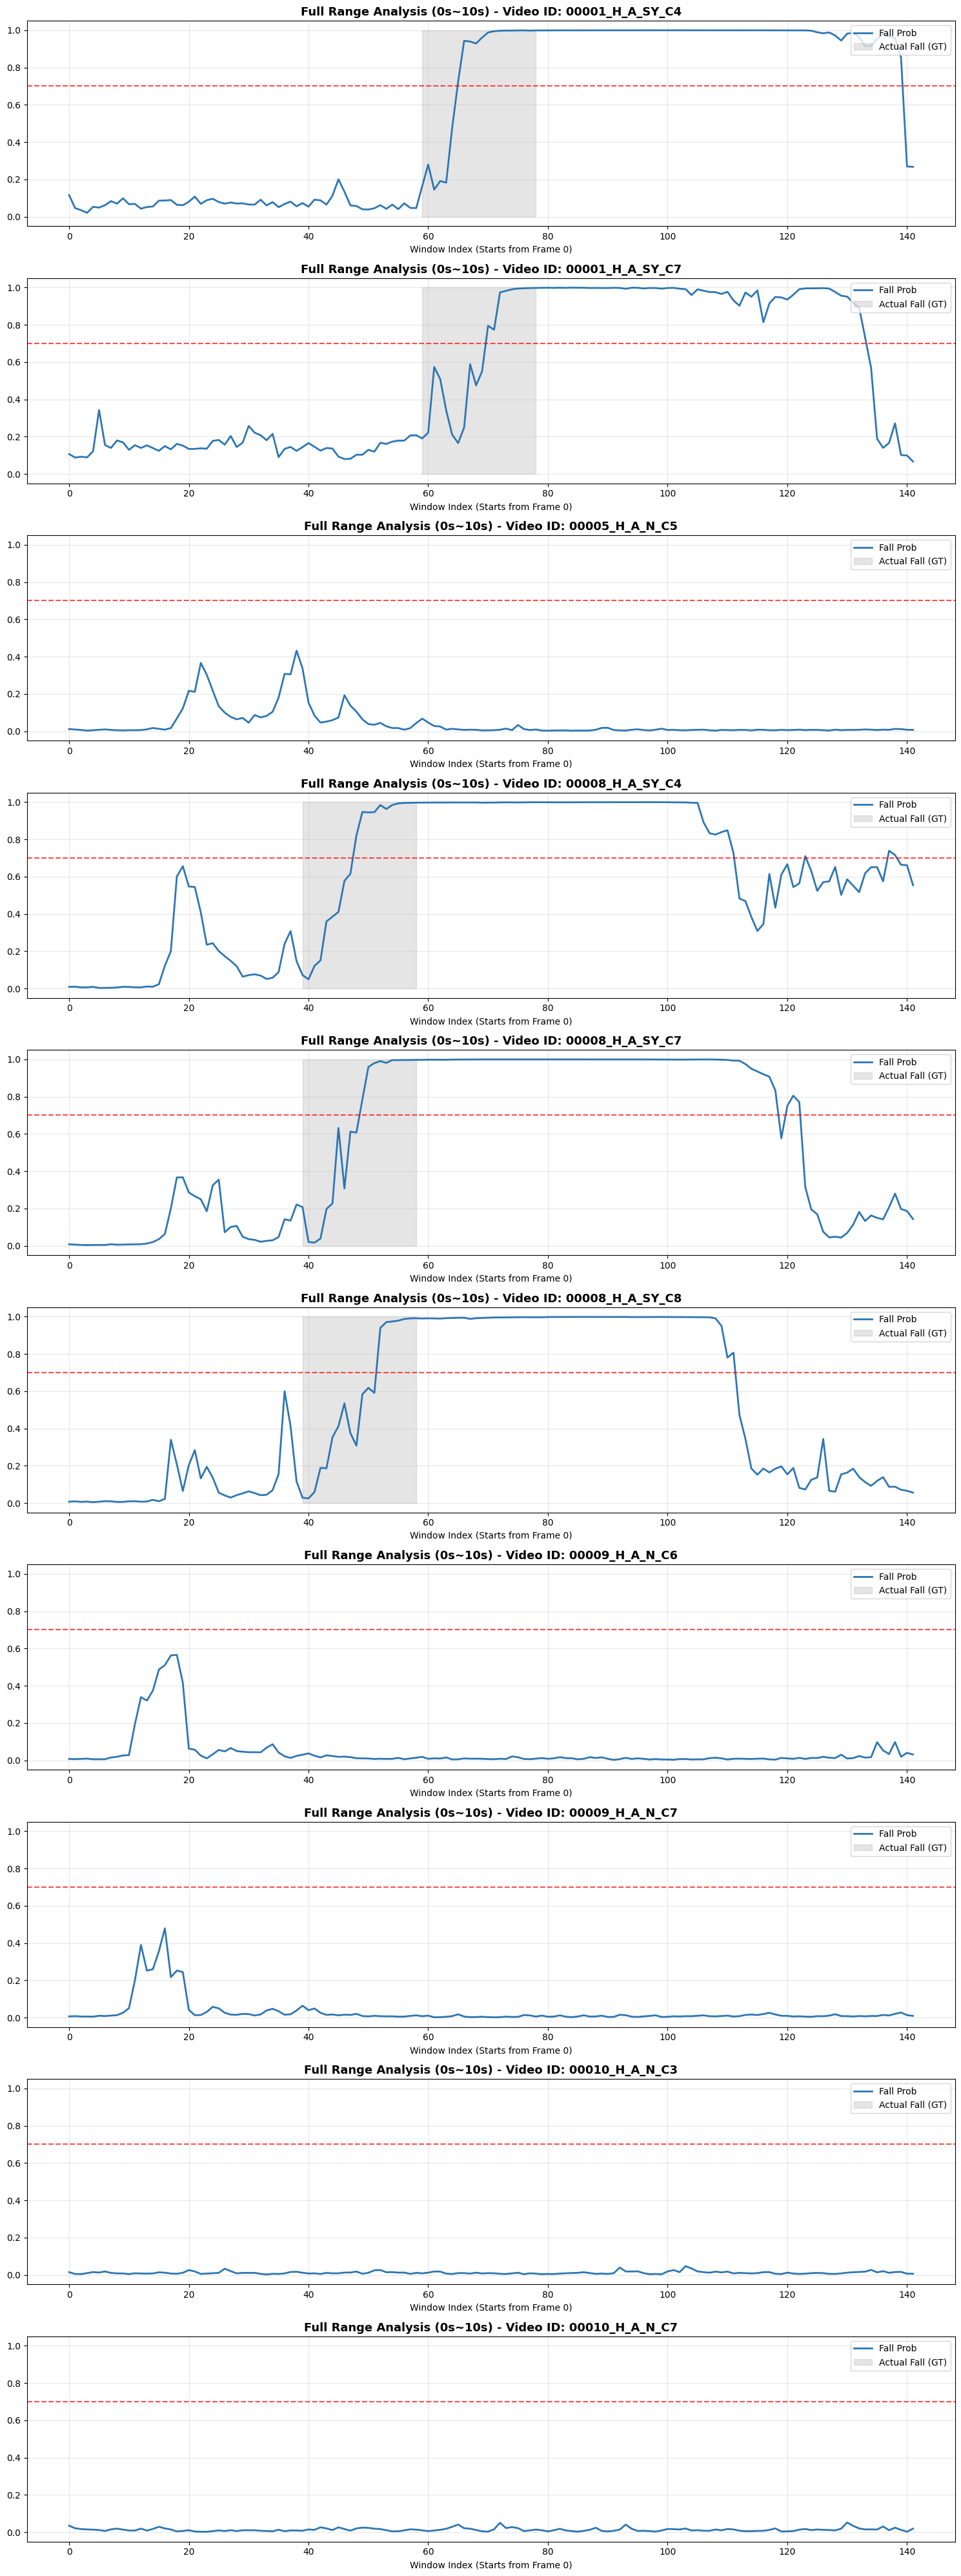

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_test_videos_full_range(df, model, group_test, feature_cols, mean, std, config, num_vids=10):
    test_video_ids = np.unique(group_test)

    selected_ids = test_video_ids[:num_vids]

    fig, axes = plt.subplots(num_vids, 1, figsize=(15, 4 * num_vids))
    if num_vids == 1: axes = [axes]

    for i, vid_id in enumerate(selected_ids):
        raw_video = df[df['video_id'] == vid_id].sort_values('frame').reset_index(drop=True)

        x_raw = raw_video[feature_cols].values
        x_norm = (x_raw - mean) / std

        full_windows = []
        for j in range(len(x_norm) - config.target_steps + 1):
            full_windows.append(x_norm[j : j + config.target_steps])

        full_windows = np.array(full_windows)

        preds = model.predict(full_windows, batch_size=256, verbose=0)
        probs = preds[:, 1]

        gt_labels = raw_video['label'].values[config.target_steps - 1:]

        ax = axes[i]
        ax.plot(probs, label='Fall Prob', color='#2E76B2', lw=2)
        ax.axhline(y=config.decision_threshold, color='red', linestyle='--', alpha=0.7)

        ax.fill_between(range(len(gt_labels)), 0, 1, where=(gt_labels == 1),
                        color='gray', alpha=0.2, label='Actual Fall (GT)')

        ax.set_title(f"Full Range Analysis (0s~10s) - Video ID: {vid_id}", fontsize=13, fontweight='bold')
        ax.set_ylim(-0.05, 1.05)
        ax.set_xlabel("Window Index (Starts from Frame 0)")
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_test_videos_full_range(df, model, group_test, feature_cols, mean, std, config, num_vids=10)

In [ ]:
# 데이터 레이블 정리
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_test_labels = np.argmax(y_test, axis=1)
else:
    y_test_labels = y_test

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. 전체 테스트 데이터에 대한 추론 수행
print(f"🚀 테스트 데이터({len(x_test)} 샘플) 성능 분석 중...")
y_pred_probs = model.predict(x_test, batch_size=256, verbose=1)[:, 1]

# 2. 설정된 임계값(0.85) 적용하여 이진 분류
y_pred_binary = (y_pred_probs >= config.decision_threshold).astype(int)

# 3. 지표 계산
# y_test_labels는 아까 정의한 (N,) 형태의 실제 정답 레이블입니다.
accuracy = accuracy_score(y_test_labels, y_pred_binary)
precision = precision_score(y_test_labels, y_pred_binary)
recall = recall_score(y_test_labels, y_pred_binary)
f1 = f1_score(y_test_labels, y_pred_binary, average='macro')
pos_rate = np.mean(y_pred_binary) # Predicted Positive Rate

# 4. 결과 출력
print("\n" + "="*30)
print(f"테스트 성능 결과 (Threshold: {config.decision_threshold})")
print("-" * 30)
print(f"Accuracy:           {accuracy:.4f}")
print(f"Precision:          {precision:.4f}")
print(f"Recall:             {recall:.4f}")
print(f"Macro F1-score:     {f1:.4f}")
print(f"Pred Positive Rate: {pos_rate:.4f}")
print("="*30)

# 상세 리포트 출력
print("\n[Classification Report]")
print(classification_report(y_test_labels, y_pred_binary, target_names=['Normal', 'Fall']))

🚀 테스트 데이터(433006 샘플) 성능 분석 중...
1692/1692 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step

테스트 성능 결과 (Threshold: 0.7)
------------------------------
Accuracy:           0.8827
Precision:          0.8617
Recall:             0.8517
Macro F1-score:     0.8787
Pred Positive Rate: 0.4069

[Classification Report]
              precision    recall  f1-score   support

      Normal       0.90      0.90      0.90    254736
        Fall       0.86      0.85      0.86    178270

    accuracy                           0.88    433006
   macro avg       0.88      0.88      0.88    433006
weighted avg       0.88      0.88      0.88    433006



In [ ]:
from google.colab import runtime
runtime.unassign()